About this notebook.

This notebook goes through all the texts and aplies on them a NLP pipeline consisting of (1) cleaning of the raw text, (2) sentence tokenization, (3) part-of-speech annotation, (4) lemmatization, and (5) named entity recognition.

The processed textual data are saved for future reuse.

In [117]:
import spacy
import os
import glob
from spacy.tokens import Doc
from spacy.language import Language
import pickle
from unidecode import unidecode
import sddk
import pandas as pd
import re
import sys
import importlib
import json
from spacy.tokens import Token
from spacy.language import Language
import google_conf
import pandas as pd
import json
import fitz
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [118]:
emlap_catalogue = google_conf.setup(sheet_url="https://docs.google.com/spreadsheets/d/1QfepoyysD1Cu12KcMAMfc6gqGzXzVUekPtXDbxLixr4/edit?usp=sharing", service_account_path="../../../ServiceAccountsKey.json")

In [2]:
import stanza
#stanza.download("grc")

/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
emlap_metadata = pd.read_csv("../data/emlap_metadata.csv", sep=";", index_col=0)
emlap_metadata.head(5)

,working_title,filenames,no.,is_done,is_noscemus,if_noscemus_id,AUTHORSHIP,is_one_author,#if more than 1 author skip section and choose compendium below,is_author_known,...,CONTENTS,genre,subject,SOURCE OF FILE,link,source_of_file,origin_of_copy,other_notes,tokens_N,aurhor_wd
0,"Augurello, Chrysopoeia",100001_Augurello1515_Chrysopoeia_GB_Noscemus,100001,True,True,713324.0,NaN,True,NaN,True,...,NaN,didactic poem,alchemy,NaN,https://wiki.uibk.ac.at/noscemus/Chrysopoeia,GB,Noscemus,NaN,23718,NaN
1,"Pseudo-Lull, Secretis",100002_Pseudo-Lull1518_De secretis_naturae_MDZ...,100002,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,"alchemy, medicine",NaN,https://www.digitale-sammlungen.de/en/view/bsb...,MDZ,MBS,NaN,24673,NaN
2,"Pantheus, Ars Transmutatione",100003_Pantheus1518_Ars_Transmutationis_Metall...,100003,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,alchemy,NaN,https://www.google.co.uk/books/edition/Ars_Tra...,GB,BL,NaN,8646,NaN
3,"Anon, Vera alchemiae",100004_Anon1561_Verae_Alchemiae_MDZ_MBS,100004,True,False,NaN,NaN,True,NaN,True,...,NaN,"compendium, florilegium",alchemy,NaN,https://mdz-nbn-resolving.de/details:bsb10141168,MDZ,MBS,NaN,3521,NaN
4,"Pantheus, Voarchadumia",100005_Pantheus1530_Voarchadumia_ONB,100005,True,False,NaN,NaN,True,NaN,True,...,NaN,treatise,alchemy,NaN,https://data.onb.ac.at/rep/10588E49,ONB,ONB,NaN,20386,NaN


In [4]:
row = emlap_metadata.loc[emlap_metadata["no."]==100001].iloc[0]

In [5]:
row["working_title"]

'Augurello, Chrysopoeia'

In [6]:
import json
import ast
import re

def parse_messy_json(text):
    if not isinstance(text, str):
        return None

    # 1. Try strict JSON first
    try:
        return json.loads(text)
    except Exception:
        pass

    # 2. Fix common issues
    fixed = text.strip()

    # Replace single quotes with double quotes when appropriate
    fixed = fixed.replace("'", '"')

    # Remove trailing commas before ] or }
    fixed = re.sub(r",\s*([}\]])", r"\1", fixed)

    # Ensure keys are quoted (naively, but works for your case)
    fixed = re.sub(r"(?<=\{|\s)([A-Za-z_][A-Za-z0-9_]*)(?=\s*:)", r'"\1"', fixed)

    # 3. Try JSON again
    try:
        return json.loads(fixed)
    except Exception:
        pass

    # 4. Try Python literal (safer than eval)
    try:
        return ast.literal_eval(text)
    except Exception:
        pass

    # 5. Give up
    return None

In [7]:
emlap_metadata["if_compendium_parsed"] = emlap_metadata["if_compendium"].apply(parse_messy_json).tolist()

In [8]:
len(emlap_metadata)

100

In [9]:
#filename_id_dict = dict(zip(emlap_metadata["filename"], emlap_metadata["No."]))

For preprocessing the latin texts, we will use a module located outside of the current repository, specifically at the same level one level up.

The module can be clonned from here: https://github.com/CCS-ZCU/latin-preprocessing and imported to python following the steps below:

In [10]:
import spacy_stanza

In [11]:
greek_nlp = spacy_stanza.load_pipeline("grc")

2025-11-26 14:10:21 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-11-26 14:10:22 INFO: Loading these models for language: grc (Ancient_Greek):
| Processor | Package         |
-------------------------------
| tokenize  | proiel          |
| pos       | proiel_nocharlm |
| lemma     | proiel_nocharlm |
| depparse  | proiel_nocharlm |

2025-11-26 14:10:22 INFO: Using device: cuda
2025-11-26 14:10:22 INFO: Loading: tokenize
2025-11-26 14:10:23 INFO: Loading: pos
2025-11-26 14:10:23 INFO: Loading: lemma
2025-11-26 14:10:23 INFO: Loading: depparse
2025-11-26 14:10:23 INFO: Done loading processors!


In [12]:
doc = greek_nlp('δοκῶ μοι περὶ ὧν πυνθάνεσθε οὐκ ἀμελέτητος εἶναι')

for token in doc:
   print(f'{token.text}, lemma: {token.lemma_}, pos: {token.pos_}, dep: {token.dep_}')

δοκῶ, lemma: δοκέω, pos: VERB, dep: root
μοι, lemma: ἐγώ, pos: PRON, dep: obl:arg
περὶ, lemma: περί, pos: ADP, dep: case
ὧν, lemma: ὅς, pos: PRON, dep: obj
πυνθάνεσθε, lemma: πυνθάνομαι, pos: VERB, dep: acl
οὐκ, lemma: οὐ, pos: ADV, dep: advmod
ἀμελέτητος, lemma: ἀμελέτης, pos: NOUN, dep: ccomp
εἶναι, lemma: εἰμί, pos: AUX, dep: cop


In [173]:
#!python -m spacy download de_core_news_sm

In [174]:
de_nlp = spacy.load("de_core_news_sm")   # or md/lg if you prefer
fr_nlp = spacy.load("fr_core_news_sm")

In [13]:
# for preprocessing the latin texts, we will use a module located outside of the current repository, specifically at the same level as the current project.
current_working_directory = os.getcwd()
relative_path = '../../latin-preprocessing/' # change according to your location...
module_path = os.path.abspath(os.path.join(current_working_directory, relative_path))
if module_path not in sys.path:
    sys.path.insert(0, module_path)
# Now import the module
import tomela

Using CPU for spaCy.


In [14]:
importlib.reload(tomela)

Using CPU for spaCy.


<module 'tomela' from '/home/jupyter-vojta/notebooks/latin-preprocessing/tomela/__init__.py'>

In [15]:
tomela.nlp.pipeline

[('senter', <spacy.pipeline.senter.SentenceRecognizer at 0x78e5b0887bf0>),
 ('normer', <function la_core_web_lg.functions.normer(doc)>),
 ('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x78e5b0887cb0>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x78e5b0887fb0>),
 ('morphologizer',
  <spacy.pipeline.morphologizer.Morphologizer at 0x78e5b0887dd0>),
 ('trainable_lemmatizer',
  <spacy.pipeline.edit_tree_lemmatizer.EditTreeLemmatizer at 0x78e5b0887f50>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x78e591b8c580>),
 ('lookup_lemmatizer',
  <function la_core_web_lg.functions.make_lookup_lemmatizer_function(doc)>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x78e591b8fdf0>),
 ('remorpher', <function la_core_web_lg.functions.remorpher(doc)>)]

In [16]:
tomela.nlp.max_length = 4000000

In [17]:
doc = tomela.nlp("Veritas, vt vlla dicit, semper est universalis et a principiis fundamentalis oritur (lib. 3, cap. VI)")
for token in doc:
    print((token.text, token.lemma_, token.pos_))

('Veritas', 'ueritas', 'NOUN')
(',', ',', 'PUNCT')
('vt', 'vt', 'ADV')
('vlla', 'vllus', 'NOUN')
('dicit', 'dico', 'VERB')
(',', ',', 'PUNCT')
('semper', 'semper', 'ADV')
('est', 'sum', 'AUX')
('universalis', 'uniuersalis', 'ADJ')
('et', 'et', 'CCONJ')
('a', 'ab', 'ADP')
('principiis', 'principium', 'NOUN')
('fundamentalis', 'fundamentalis', 'ADJ')
('oritur', 'orior', 'VERB')
('(lib', '(lib', 'NOUN')
('.', '.', 'PUNCT')
('3', '3', 'NUM')
(',', ',', 'PUNCT')
('cap', 'capitulum', 'NOUN')
('.', '.', 'PUNCT')
('VI', 'uis', 'NUM')
(')', ')', 'PUNCT')


In [18]:
source_path = "/srv/data/tome/tome-corpus/EMLAP_2025-10-31/annotated_textblocks/"
len(os.listdir(source_path))

200

In [19]:
import shutil
shutil.copytree("/srv/data/tome/tome-corpus/EMLAP_2025-10-31/annotated_textblocks/", "../data/emlap_annotated_textblocks/", dirs_exist_ok=True)

'../data/emlap_annotated_textblocks/'

In [20]:
[f for f in sorted(os.listdir(source_path)) if "_params" not in f]

['100001_Augurello1515_Chrysopoeia_GB_Noscemus.json',
 '100002_Pseudo-Lull1518_De_secretis_naturae_MDZ_MBS.json',
 '100003_Pantheus1518_Ars_Transmutationis_Metallicae_BL_GB.json',
 '100004_Anon1561_Verae_Alchemiae_MDZ_MBS.json',
 '100005_Pantheus1530_Voarchadumia_ONB.json',
 '100006_Savonarola1532_De_arte_conficiendi_aquam_vitae_ONB.json',
 '100007_Anon1550_Rosarium_philosophorum_ER_ZZ.json',
 '100008_Severinus1572_Epistola_MBZ_MBS.json',
 '100009_Vegius1518_Inter_inferiora_corpora_disputatio_ONB.json',
 '100010_Bracesco1548_De_alchemia_dialogi_duo_IA_Madrid.json',
 '100011_Anon1541_De_alchemia_MDZ_MBS.json',
 '100012_Gessner1552_Thesaurus_Euonymi_Philiatri_ER_ZZ.json',
 '100013_Ulstad1525_Coelum_philosophorum_Medica_BIUSP.json',
 '100014_Toxites1567_Spongia_stibii_MDZ_MBS.json',
 '100015_Gessner1569_Thesaurus_Euonymi_Philiatri_liber_secundus_MDZ_MBS.json',
 '100016_Bonus1546_Pretiosa_Margarita_Novella_ONB.json',
 '100017_Bodenstein1559_Isagoge_MDZ_MBS.json',
 '100018_Trevisanus1567_Pe

In [21]:
row = emlap_metadata.loc[emlap_metadata["no."]==int("100001")].iloc[0]
row

working_title                                                                                 Augurello, Chrysopoeia
filenames                                                               100001_Augurello1515_Chrysopoeia_GB_Noscemus
no.                                                                                                           100001
is_done                                                                                                         True
is_noscemus                                                                                                     True
if_noscemus_id                                                                                              713324.0
AUTHORSHIP                                                                                                       NaN
is_one_author                                                                                                   True
#if more than 1 author skip section and choose compendium below 

In [22]:
files_overview = []
for filename in os.listdir(source_path):
    #filename = 'DuChesne1575_Ad_Iacobi_Auberti_MDZ_Augsburg.json'
    id = int(filename[:6])
    row = emlap_metadata.loc[emlap_metadata["no."]==id].iloc[0]
    if "_params" not in filename:
        filepath = os.path.join(source_path, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            textblocks = json.load(f)
        pages_n = len(textblocks)
        chars_n = sum([sum([len(tb["text"]) for tb in p]) for p in textblocks])
        files_overview.append({"filename" : filename, "pages_n" : pages_n, "chars_n" : chars_n})
files_processed = pd.DataFrame(files_overview)
files_processed

,filename,pages_n,chars_n
0,100084_Croll1609_Basilica_chymica_MDZ_MBS.json,477,694793
1,100094_Anon1625_Musaeum_hermeticum_VD17_SLUB.json,508,694493
2,100058_Hagecius1596_Actio_medica_ER_UBB.json,89,104677
3,100013_Ulstad1525_Coelum_philosophorum_Medica_...,113,237793
4,100069_Severinus1571_Idea_medicinae_philosophi...,463,600046
...,...,...,...
95,100056_Claveus1598_Apologia_crysopoeiae_MDZ_MB...,233,233328
96,100065_Libavius1594_Neoparacelsica_MDZ_MBS.json,821,1079977
97,100031_Phaedro1562_Aquila_coelestis_MBZ_MBS.json,55,15562
98,100098_Burggravius1630_Biolychnium_VD17_SLUB.json,167,186267


In [23]:
#emlap_catalogue = google_conf.setup(sheet_url="https://docs.google.com/spreadsheets/d/1bkHHTYc86K2IuEXqfYfkDNt5LovtvCU3gvqHIbVio88/edit?usp=sharing", service_account_path="../../../ServiceAccountsKey.json")

# google_conf.set_with_dataframe(emlap_catalogue.add_worksheet("files_processed", 1,1), files_processed, include_index=False)


Develop and test with one example test

In [64]:
filename = '100085_Libavius1606_Commentariorum_alchemiae_pars_1_MDZ_MBS.json'
filepath = os.path.join(source_path, filename)
with open(filepath, 'r', encoding='utf-8') as f:
    textblocks = json.load(f)

In [65]:
textblocks_unheadered = []
for p in textblocks:
    p_unheadered = []
    header_met = False
    for textblock in p:
        if textblock["tag"] == "header":
            if header_met:
                textblock["tag"] = "text"
            else:
                header_met = True
        p_unheadered.append(textblock)
    textblocks_unheadered.append(p_unheadered)

textblocks = textblocks_unheadered#%%
len(textblocks)

413

In [193]:
textblocks[30][:10]

[{'coordinates': [211.67999267578125,
   1086.2401123046875,
   361.0691833496094,
   1091.0400390625],
  'text': '6. Aeneid.\n',
  'tag': 'margin'},
 {'coordinates': [405.6000061035156,
   200.16000366210938,
   1988.2835693359375,
   217.34410095214844],
  'text': '20\nExamen sententiae Parisiensis scholae\n',
  'tag': 'header'},
 {'coordinates': [573.3599853515625,
   284.6640930175781,
   2086.989501953125,
   289.5841064453125],
  'text': '"Si in mundo sublunari nulla est substantia ab elementaribus quatuor distincta, nulla est quinta essen¬\n',
  'tag': 'text'},
 {'coordinates': [672.47998046875,
   334.7998962402344,
   1029.914794921875,
   339.5998840332031],
  'text': 'tia, quae extrahi possit.\n',
  'tag': 'text'},
 {'coordinates': [573.3599853515625,
   384.9600524902344,
   1760.6229248046875,
   389.7600402832031],
  'text': 'Prius est. Posterius ergo: & per consequens, ignis & opera perditur extrahendo,"\n',
  'tag': 'text'},
 {'coordinates': [504.9599914550781,
   433.6

In [194]:
margin_pages = []
for p in textblocks[:50]:
    for textblock in p:
        if textblock["tag"] == "margin":
            margin_pages.append(p)
            break

In [195]:
len(margin_pages)

35

In [196]:
margin_pages[0]

[{'coordinates': [235.44000244140625,
   684.7200317382812,
   409.4384460449219,
   689.5200805664062],
  'text': 'In specie tot\n',
  'tag': 'margin'},
 {'coordinates': [235.44000244140625,
   725.0398559570312,
   410.12158203125,
   729.8399047851562],
  'text': 'medicorum\n',
  'tag': 'margin'},
 {'coordinates': [235.44000244140625,
   765.8640747070312,
   409.9117736816406,
   770.7840576171875],
  'text': 'hodie sectae,\n',
  'tag': 'margin'},
 {'coordinates': [240.24000549316406,
   806.3999633789062,
   399.8396301269531,
   811.2000122070312],
  'text': 'vt videan¬\n',
  'tag': 'margin'},
 {'coordinates': [237.83999633789062,
   846.2639770507812,
   409.64459228515625,
   851.1839599609375],
  'text': 'tur innume¬\n',
  'tag': 'margin'},
 {'coordinates': [237.83999633789062,
   885.8640747070312,
   410.22802734375,
   890.7840576171875],
  'text': 'rabila, gene¬\n',
  'tag': 'margin'},
 {'coordinates': [237.83999633789062,
   929.0398559570312,
   394.5736389160156,
   933

In [197]:
margin_pages[1]

[{'coordinates': [526.0800170898438,
   172.10403442382812,
   1639.3897705078125,
   177.02403259277344],
  'text': 'EPISTOLA DEDICATORIA.\n',
  'tag': 'header'},
 {'coordinates': [337.9200134277344,
   262.1040344238281,
   1993.8466796875,
   267.0240478515625],
  'text': 'Nullus quidem Paracelsita quicquam sibi commune cum schola\n',
  'tag': 'text'},
 {'coordinates': [194.63999938964844,
   338.9038391113281,
   1991.999755859375,
   343.8238525390625],
  'text': 'Galenica esse prae se videtur ferre: aliqui tamen Hippocrati sunt aequio¬\n',
  'tag': 'text'},
 {'coordinates': [181.44000244140625,
   417.8399353027344,
   1995.948486328125,
   422.6399230957031],
  'text': 'res: Hic reijcit Chrysopoeian, ille magian, adiurationes, execrationes ec.\n',
  'tag': 'text'},
 {'coordinates': [185.75999450683594,
   495.3838195800781,
   1972.9329833984375,
   500.3038330078125],
  'text': 'Puri puti Paracelsici omnia atque etiam sputa sui Monarchae exosculan¬\n',
  'tag': 'text'},
 {'coor

In [198]:
for p in textblocks[:50]:
    for t in p:
        if "[" in t["text"]:
            print(t)

{'coordinates': [384.0, 2262.9599609375, 2165.489013671875, 2267.760009765625], 'text': '[GR]χιμικώτερα[/GR] essent seligere, dissentientiaquè componere. Itaque & nouam\n', 'tag': 'text'}
{'coordinates': [139.1999969482422, 3188.159912109375, 1914.183349609375, 3192.9599609375], 'text': 'quoddam [GR]μιγμα[/GR] & commentum ab omni veritate alienum. Sed ostendendum est veram artem nec\n', 'tag': 'text'}
{'coordinates': [398.1600036621094, 511.6800231933594, 2167.622314453125, 516.4800415039062], 'text': 'longe abest à [GR]πανσπερμία[/GR] illa vetere, & atomis Democriti, & multiplici vicissim oriente & pereunte? Sed\n', 'tag': 'text'}
{'coordinates': [390.7200012207031, 2782.079833984375, 2149.680419921875, 2786.8798828125], 'text': 'quętis [GR]σκευασταί καὶ πυροτεηνίαν[/GR], ecce tibi eundem Bulcasim passim inseruientem. Fornaces enim seu Atha¬\n', 'tag': 'text'}
{'coordinates': [198.24000549316406, 1149.1199951171875, 1980.812744140625, 1153.919921875], 'text': 'potest. "Nec ego (inquit

In [199]:
for p in textblocks:
    for t in p:
        if "[/S]" in t["text"]:
            print(t)

{'coordinates': [225.83999633789062, 905.7598266601562, 387.3038635253906, 910.5598754882812], 'text': 'Olei [S]y[/S]. j. ex\n', 'tag': 'margin'}
{'coordinates': [429.1199951171875, 1108.5599365234375, 2191.517578125, 1113.35986328125], 'text': 'crassos. Dosis eius solius [S]z[/S] ij. vsque ad [S]z[/S] iiij. cum aqua frigida. Similia habet Mesues lib simplicium, cap. 16.\n', 'tag': 'text'}
{'coordinates': [241.9199981689453, 2369.999755859375, 407.46197509765625, 2374.7998046875], 'text': 'trahe [S][/S], ex\n', 'tag': 'margin'}
{'coordinates': [234.72000122070312, 2417.999755859375, 407.2383728027344, 2422.7998046875], 'text': 'hoc\xa0[S][/S], & i¬\n', 'tag': 'margin'}
{'coordinates': [424.0799865722656, 312.7200622558594, 2143.775634765625, 317.5200500488281], 'text': 'Lunam, Venerem, Martem, Saturnum, louem; signare vero more astrologorum,\xa0[S]Mercurius[/S],\xa0[S]Sol[/S],\xa0[S]Luna[/S],\xa0[S]Venus[/S],\xa0[S]Mars[/S],\xa0[S]Saturnus[/S],\xa0[S]Jupiter[/S].\n', 'tag': 'text'}
{'c

In [200]:
for p in textblocks:
    for t in p:
        if "[G]" in t["text"]:
            print(t)

{'coordinates': [190.55999755859375, 3375.35986328125, 2012.520263671875, 3380.159912109375], 'text': 'tes quosdam de re rustica scriptores hanc indignam Philosophis seueris vocem: [G]Es ist vil besser daß das\n[/G]', 'tag': 'text'}
{'coordinates': [197.27999877929688, 3473.519775390625, 2018.2967529296875, 3478.31982421875], 'text': '[G]vnd geringe haußhaltung ist / gebuerth der frawen im hause zu[/G]. hoc est: multo melius est mulieres tractare\n', 'tag': 'text'}
{'coordinates': [398.8800048828125, 577.9199829101562, 2197.105712890625, 582.7200317382812], 'text': 'decet addere, notum est. Appellant [G]gestub[/G] & eo focos instruunt, aliterque vtuntur. (Hinc illa phrasis\n', 'tag': 'text'}
{'coordinates': [398.8800048828125, 628.7998657226562, 2206.61669921875, 633.5999145507812], 'text': 'cum rumpitur stratum luteum & cinericium fulminatorii, aut fornacum excoctoriarum [G]das gestub\n[/G]', 'tag': 'text'}
{'coordinates': [401.2799987792969, 681.8399047851562, 659.7328491210938, 686.

In [375]:
import re
import unicodedata
from spacy.tokens import Token, Doc
from spacy.language import Language


# =============================================================================
# 0. EXTERNAL MODELS (YOU MUST SUPPLY THEM)
# =============================================================================

# Latin model (your tomela.nlp)
nlp_latin = tomela.nlp

LANG_PIPELINES = {
    "GR": greek_nlp,   # Greek
    "G":  de_nlp,      # German
    "F":  fr_nlp       # French
    # I, H, D → no dedicated pipeline
}

SUPPORTED_LANGUAGE_TAGS = {"GR", "G", "F", "I", "H", "D"}
DEEP_PIPELINE_TAGS = {"GR", "G", "F"}   # have NLP models
SHALLOW_TAGS = {"I", "H", "D"}          # metadata-only


# =============================================================================
# 1. TOKEN / DOC EXTENSIONS
# =============================================================================

for ext, default in [
    ("pages", None),
    ("textblocks", None),
    ("tags", None),
    ("block_type", None),
]:
    if not Token.has_extension(ext):
        Token.set_extension(ext, default=default)

if not Token.has_extension("ml_data"):
    Token.set_extension("ml_data", default={})

if not Doc.has_extension("char_to_source"):
    Doc.set_extension("char_to_source", default=None)


# =============================================================================
# 2. RAW TAG EXTRACTION (per textblock)
# =============================================================================

TAG_REGEX = re.compile(r"\[(?P<tag>[A-Za-z]+)]|\[/(?P<etag>[A-Za-z]+)]")
GREEK_RE = re.compile(r"[\u0370-\u03FF\u1F00-\u1FFF]")


def extract_tags_from_raw(raw_text: str):
    """
    Assigns tags to RAW character indices based on inline markup.

    Rules:
      GR:
        - any Greek Unicode char → "GR"
      S:
        - [S]...[/S] tags ONLY characters strictly between markers
        - lone [S] (no [/S]) tags the next TOKEN (stop at whitespace or '[')
      G, F, I, H, D:
        - [TAG]...[/TAG] tag spans
        - lone [TAG] tags the next token
    """
    raw_tags = {}  # raw_idx -> set[str]

    # --- detect all markup tags
    matches = list(TAG_REGEX.finditer(raw_text))

    # ----------------------------------------------------------------------
    # 1) Greek by Unicode, always independent of tag markup
    # ----------------------------------------------------------------------
    for i, ch in enumerate(raw_text):
        if GREEK_RE.match(ch):
            raw_tags.setdefault(i, set()).add("GR")

    # ----------------------------------------------------------------------
    # 2) Apply S spans FIRST — because S is special (symbols only)
    # ----------------------------------------------------------------------
    def apply_S_spans():
        open_stack = []

        # Identify all opening/closing tags
        for m in matches:
            tag  = m.group("tag")
            etag = m.group("etag")

            if tag == "S":
                open_stack.append(m)
            elif etag == "S":
                # match to most recent open
                for j in range(len(open_stack) - 1, -1, -1):
                    om = open_stack[j]
                    if om is None:
                        continue
                    start = om.end()       # after "[S]"
                    end   = m.start()      # before "[/S]"
                    for idx in range(start, end):
                        raw_tags.setdefault(idx, set()).add("S")
                    open_stack[j] = None
                    break

        # Lone opens: tag next TOKEN only
        for om in open_stack:
            if om is None:
                continue
            i = om.end()
            n = len(raw_text)
            while i < n and not raw_text[i].isspace():
                if raw_text[i] == "[":
                    break
                raw_tags.setdefault(i, set()).add("S")
                i += 1

    apply_S_spans()

    # ----------------------------------------------------------------------
    # 3) Apply all language-tag spans (G, F, I, H, D)
    #     (GR is also a tag type, but GR Unicode is the real marker)
    # ----------------------------------------------------------------------
    def apply_language_spans(label: str):
        open_stack = []

        for m in matches:
            tag  = m.group("tag")
            etag = m.group("etag")

            if tag == label:
                open_stack.append(m)
            elif etag == label:
                # close most recent unmatched open
                for j in range(len(open_stack) - 1, -1, -1):
                    om = open_stack[j]
                    if om is None:
                        continue
                    start = om.end()
                    end   = m.start()
                    for idx in range(start, end):
                        raw_tags.setdefault(idx, set()).add(label)
                    open_stack[j] = None
                    break

        # lone opening tag → tag next token
        for om in open_stack:
            if om is None:
                continue
            i = om.end()
            n = len(raw_text)
            while i < n and not raw_text[i].isspace():
                if raw_text[i] == "[":
                    break
                raw_tags.setdefault(i, set()).add(label)
                i += 1

    # Apply language tags (exclude S — already processed)
    for lang in SUPPORTED_LANGUAGE_TAGS:
        if lang == "S":
            continue
        apply_language_spans(lang)

    return raw_tags

# =============================================================================
# 3. PER-BLOCK CLEANING + TAGGING (raw -> clean)
# =============================================================================

def _clean_block_with_mapping(raw_text: str, page_idx: int, tb_idx: int, tb_tag: str):
    """
    Convert a raw textblock into a cleaned text (no markup tags) and
    a char_src mapping: clean_idx -> {page_idx, textblock_idx, textblock_type, tags}.

    Key points:
      - We NEVER build a separate raw→clean map and then project tags.
        Instead, we:
          * extract tags on raw indices once
          * walk raw_text left-to-right
          * skip markup [TAG] and [/TAG]
          * at each *content* char, we:
              - look up tags at this raw index
              - do minimal OCR cleaning (Latin context only)
              - emit zero or more clean characters
              - attach the tags directly to the emitted clean character(s)

      → This completely avoids the drift that caused [S] to spill onto
        'quas notas' etc.
    """
    raw_tags = extract_tags_from_raw(raw_text)

    clean_chars = []
    char_src_block = {}

    i = 0
    n = len(raw_text)

    while i < n:
        ch = raw_text[i]

        # --- 3.1 Skip markup [TAG]... markers entirely ---
        if ch == "[":
            m = TAG_REGEX.match(raw_text, i)
            if m:
                # Do not emit any characters for the markup itself
                i = m.end()
                continue
            # malformed "[": fall through and treat as content

        # --- 3.2 Tags active at this raw position ---
        tags_here = set(raw_tags.get(i, set()))

        # Auto-add GR if the actual character is Greek
        if GREEK_RE.match(ch):
            tags_here.add("GR")

        lang_here = tags_here & SUPPORTED_LANGUAGE_TAGS
        in_latin_context = not lang_here  # no explicit language tag → treat as Latin/OCR

        # --- 3.3 OCR / normalization rules ---

        # NBSP & newline → spaces (for everyone)
        if ch == "\xa0" or ch == "\n":
            if clean_chars and clean_chars[-1] == " ":
                i += 1
                continue
            clean_idx = len(clean_chars)
            clean_chars.append(" ")
            char_src_block[clean_idx] = {
                "page_idx": page_idx,
                "textblock_idx": tb_idx,
                "textblock_type": tb_tag,
                "tags": sorted(tags_here) if tags_here else None,
            }
            i += 1
            continue

        # Latin-only hyphenation artifact "¬\n" → drop both
        if in_latin_context and ch == "¬":
            if i + 1 < n and raw_text[i + 1] == "\n":
                i += 2
                continue
            # lone "¬" → drop
            i += 1
            continue

        # Latin-only "ß" -> "ss"
        if in_latin_context and ch == "ß":
            for c_out in ("s", "s"):
                clean_idx = len(clean_chars)
                clean_chars.append(c_out)
                char_src_block[clean_idx] = {
                    "page_idx": page_idx,
                    "textblock_idx": tb_idx,
                    "textblock_type": tb_tag,
                    "tags": sorted(tags_here) if tags_here else None,
                }
            i += 1
            continue

        # Latin-only "ij" -> "ii"
        if in_latin_context and ch == "i" and i + 1 < n and raw_text[i + 1] == "j":
            for c_out in ("i", "i"):
                clean_idx = len(clean_chars)
                clean_chars.append(c_out)
                char_src_block[clean_idx] = {
                    "page_idx": page_idx,
                    "textblock_idx": tb_idx,
                    "textblock_type": tb_tag,
                    "tags": sorted(tags_here) if tags_here else None,
                }
            i += 2
            continue

        # Latin-only v/V -> u/U
        if in_latin_context and ch == "v":
            ch_out = "u"
        elif in_latin_context and ch == "V":
            ch_out = "U"
        else:
            ch_out = ch

        # Normalize (safe for all languages)
        ch_out = unicodedata.normalize("NFC", ch_out)

        # (Optional) basic whitespace collapse for spaces
        if ch_out == " " and clean_chars and clean_chars[-1] == " ":
            i += 1
            continue

        clean_idx = len(clean_chars)
        clean_chars.append(ch_out)
        char_src_block[clean_idx] = {
            "page_idx": page_idx,
            "textblock_idx": tb_idx,
            "textblock_type": tb_tag,
            "tags": sorted(tags_here) if tags_here else None,
        }

        i += 1

    return "".join(clean_chars), char_src_block


# =============================================================================
# 4. BUILD FULL CLEAN TEXT (MAIN + MARGINS)
# =============================================================================

def _process_textblocks_for_tags(textblocks, allowed_tags):
    """
    Build a single cleaned text string and per-character source metadata
    for a subset of textblock types (e.g. {"text","title"} or {"margin"}).

    Returns:
      clean_full : str
      char_src   : dict[int -> {page_idx, textblock_idx, textblock_type, tags}]
    """
    clean_full = ""
    char_src = {}
    offset = 0

    for page_idx, page in enumerate(textblocks):
        for tb_idx, tb in enumerate(page):
            if tb["tag"] not in allowed_tags:
                continue

            raw = tb["text"]
            clean_block, src_block = _clean_block_with_mapping(
                raw_text=raw,
                page_idx=page_idx,
                tb_idx=tb_idx,
                tb_tag=tb["tag"],
            )

            # shift local indices into global clean_full space
            for local_idx, info in src_block.items():
                global_idx = offset + local_idx
                char_src[global_idx] = info

            clean_full += clean_block
            offset += len(clean_block)

    return clean_full, char_src


# =============================================================================
# 5. HIGH-LEVEL PROCESSOR (MAIN + MARGINS)
# =============================================================================

def process_with_source_tracking(textblocks, nlp):
    """
    Returns two docs with identical pipeline structure but different sources:

      doc_main    – textblocks tagged {"text", "title"}
      doc_margins – textblocks tagged {"margin"}

    All page / textblock / language / symbol tags are encoded in
    doc._.char_to_source and then propagated to tokens by source_tracker.
    """

    # MAIN
    clean_main, src_main = _process_textblocks_for_tags(
        textblocks, allowed_tags={"text", "title"}
    )
    doc_main = nlp.make_doc(clean_main)
    doc_main._.char_to_source = src_main
    for name, proc in nlp.pipeline:
        doc_main = proc(doc_main)

    # MARGINS
    clean_marg, src_marg = _process_textblocks_for_tags(
        textblocks, allowed_tags={"margin"}
    )
    doc_marg = nlp.make_doc(clean_marg)
    doc_marg._.char_to_source = src_marg
    for name, proc in nlp.pipeline:
        doc_marg = proc(doc_marg)

    return doc_main, doc_marg


# =============================================================================
# 6. SOURCE TRACKER
# =============================================================================

@Language.component("source_tracker")
def source_tracker(doc):
    cts = doc._.char_to_source
    if cts is None:
        return doc

    for tok in doc:
        pages, tbs, btypes, tags = set(), set(), set(), set()

        for i in range(tok.idx, tok.idx + len(tok.text)):
            info = cts.get(i)
            if not info:
                continue
            pages.add(info["page_idx"])
            tbs.add(info["textblock_idx"])
            bt = info.get("textblock_type")
            if bt:
                btypes.add(bt)
            tag_list = info.get("tags")
            if tag_list:
                tags.update(tag_list)

        tok._.pages = sorted(pages) or None
        tok._.textblocks = sorted(tbs) or None
        tok._.block_type = next(iter(btypes)) if btypes else "text"
        tok._.tags = sorted(tags) or None

    return doc


# =============================================================================
# 7. BLOCKTYPE-BASED SENTENCIZER
# =============================================================================

@Language.component("blocktype_sentencizer")
def blocktype_sentencizer(doc):
    prev_bt = None
    for tok in doc:
        bt = tok._.block_type
        if prev_bt is None or bt != prev_bt:
            tok.is_sent_start = True
        prev_bt = bt
    return doc


# =============================================================================
# 8. MULTILINGUAL ENRICHER
# =============================================================================

@Language.component("multilingual_enricher")
def multilingual_enricher(doc):
    """
    Post-hoc enrichment for tokens whose ._.tags include language labels.

    - For GR / G / F:
        run the corresponding external spaCy pipeline on contiguous spans
        and copy lemma / pos / morph into token._.ml_data.
    - For I / H / D:
        no external pipeline → we only record metadata; lemma fallback
        can be handled in doc_to_sent_dicts (e.g. lemma=token.text).
    """

    # 8.1 collect contiguous spans for GR/G/F
    spans = {lang: [] for lang in DEEP_PIPELINE_TAGS}

    for lang in DEEP_PIPELINE_TAGS:
        cur = []
        for tok in doc:
            if tok._.tags and lang in tok._.tags:
                cur.append(tok)
            else:
                if cur:
                    spans[lang].append(cur)
                    cur = []
        if cur:
            spans[lang].append(cur)

    # 8.2 run external models for GR/G/F
    for lang, spanlists in spans.items():
        nlp_model = LANG_PIPELINES[lang]
        if not spanlists:
            continue

        for toklist in spanlists:
            s0 = toklist[0].i
            s1 = toklist[-1].i + 1
            subspan = doc[s0:s1]

            gdoc = nlp_model(subspan.text)
            g_tokens = list(gdoc)

            for ltok, gtok in zip(subspan, g_tokens):
                if not (ltok._.tags and lang in ltok._.tags):
                    continue
                ltok._.ml_data = {
                    "language": lang,
                    "lemma": gtok.lemma_,
                    "pos": gtok.pos_,
                    "morph": gtok.morph.to_dict(),
                }
                # override Latin analysis
                ltok.lemma_ = gtok.lemma_
                ltok.pos_ = gtok.pos_

    # 8.3 shallow languages (I, H, D): metadata only
    for tok in doc:
        if not tok._.tags:
            continue
        shallow = set(tok._.tags) & SHALLOW_TAGS
        if not shallow:
            continue
        tok._.ml_data = tok._.ml_data or {}
        tok._.ml_data.setdefault("languages", sorted(shallow))

    return doc


# =============================================================================
# 9. REGISTER COMPONENTS IN LATIN PIPELINE
# =============================================================================

if "source_tracker" in nlp_latin.pipe_names:
    nlp_latin.remove_pipe("source_tracker")
nlp_latin.add_pipe(
    "source_tracker",
    before="senter" if "senter" in nlp_latin.pipe_names else nlp_latin.pipe_names[0]
    if nlp_latin.pipe_names else None,
)

if "blocktype_sentencizer" in nlp_latin.pipe_names:
    nlp_latin.remove_pipe("blocktype_sentencizer")
nlp_latin.add_pipe("blocktype_sentencizer", after="source_tracker")

if "multilingual_enricher" in nlp_latin.pipe_names:
    nlp_latin.remove_pipe("multilingual_enricher")
nlp_latin.add_pipe("multilingual_enricher", last=True)

<function __main__.multilingual_enricher(doc)>

In [376]:
doc, doc_margins = process_with_source_tracking(textblocks[:100], nlp_latin)

In [377]:
for t in doc:
    if t._.tags:
        print(
            repr(t.text),
            "tags=", t._.tags,
            "lemma=", t.lemma_,
            "ml_data=", t._.ml_data
        )

'χιμικωτερα' tags= ['GR'] lemma= χιμικός ml_data= {'language': 'GR', 'lemma': 'χιμικός', 'pos': 'ADJ', 'morph': {'Case': 'Nom', 'Degree': 'Cmp', 'Gender': 'Neut', 'Number': 'Plur'}}
'μιγμα' tags= ['GR'] lemma= μιγμα ml_data= {'language': 'GR', 'lemma': 'μιγμα', 'pos': 'INTJ', 'morph': {}}
'πανσπερμια' tags= ['GR'] lemma= πανσπερμια ml_data= {'language': 'GR', 'lemma': 'πανσπερμια', 'pos': 'INTJ', 'morph': {}}
'σκευασται' tags= ['GR'] lemma= σκευαά ml_data= {'language': 'GR', 'lemma': 'σκευαά', 'pos': 'NOUN', 'morph': {'Case': 'Nom', 'Gender': 'Fem', 'Number': 'Sing'}}
'και' tags= ['GR'] lemma= και ml_data= {'language': 'GR', 'lemma': 'και', 'pos': 'NOUN', 'morph': {}}
'πυροτεηνιαν' tags= ['GR'] lemma= πυροτεηνιανή ml_data= {'language': 'GR', 'lemma': 'πυροτεηνιανή', 'pos': 'NOUN', 'morph': {}}
'κακοηθειαν' tags= ['GR'] lemma= κακοήθειος ml_data= {'language': 'GR', 'lemma': 'κακοήθειος', 'pos': 'ADJ', 'morph': {'Case': 'Nom', 'Degree': 'Pos', 'Gender': 'Fem', 'Number': 'Sing'}}
'δπιχαιρ

In [378]:
for t in doc:
    if t._.tags:
        if "G" in t._.tags:
            print(
                repr(t.text),
                "tags=", t._.tags,
                "lemma=", t.lemma_,
                "ml_data=", t._.ml_data,
                "page=", t._.pages,
                "textblocks=", t._.textblocks,
            )

'Es' tags= ['G'] lemma= es ml_data= {'language': 'G', 'lemma': 'es', 'pos': 'PRON', 'morph': {'Case': 'Nom', 'Gender': 'Neut', 'Number': 'Sing', 'Person': '3', 'PronType': 'Prs'}} page= [91] textblocks= [64]
'ist' tags= ['G'] lemma= sein ml_data= {'language': 'G', 'lemma': 'sein', 'pos': 'AUX', 'morph': {'Mood': 'Ind', 'Number': 'Sing', 'Person': '3', 'Tense': 'Pres', 'VerbForm': 'Fin'}} page= [91] textblocks= [64]
'vil' tags= ['G'] lemma= vil ml_data= {'language': 'G', 'lemma': 'vil', 'pos': 'ADP', 'morph': {}} page= [91] textblocks= [64]
'besser' tags= ['G'] lemma= gut ml_data= {'language': 'G', 'lemma': 'gut', 'pos': 'ADV', 'morph': {'Degree': 'Cmp'}} page= [91] textblocks= [64]
'daß' tags= ['G'] lemma= daß ml_data= {'language': 'G', 'lemma': 'daß', 'pos': 'SCONJ', 'morph': {}} page= [91] textblocks= [64]
'das' tags= ['G'] lemma= der ml_data= {'language': 'G', 'lemma': 'der', 'pos': 'PRON', 'morph': {'Case': 'Nom', 'Gender': 'Neut', 'Number': 'Sing', 'PronType': 'Dem'}} page= [91] t

In [379]:
textblocks[121][45]

{'coordinates': [528.719970703125,
  2460.239990234375,
  1511.9150390625,
  2465.0400390625],
 'text': 'Furnus vstorius argenti, seu vstrina sub tegula.\n',
 'tag': 'text'}

In [380]:
for sent in [sent for sent in doc_margins.sents][:10]:
    print(sent.text)

In specie tot medicorum hodie sectae, ut uideantur innumerabila, genere ad tres classes reduci possunt.
Galenici ingenui.
Chymiatri uulgares seu simplices.
Chymiatri hermetici.
Chymiatri.
sophistici, non parum paracelsici, licet hoc nomen auersentur.
Talis fuit Assyluanus.
Paracelsici.
Hemiparacelsici.
Heloparacelsici.


In [381]:
def doc_to_sent_dicts(doc, work_id):
    """
    Convert a spaCy Doc into the final v2 JSON sentence structure.
    Supports multilingual overrides:
      - Greek (GR)
      - German (G)
      - French (F)
    via token._.ml_data inserted by multilingual_enricher.

    Guarantees:
      - tags always a list (never None)
      - lemma/pos overridden correctly for tagged spans
      - ref metadata fully preserved for later merging
    """

    sent_dicts = []

    for sent_id, sent in enumerate(doc.sents):

        sent_tokens = []
        sent_start = sent.start_char

        for t in sent:

            # -------------------------------------------------
            # 1. MULTILINGUAL OVERRIDE (GR, G, F)
            # -------------------------------------------------
            lemma = None
            pos = None

            # tags = list or [] (never None)
            tags = list(t._.tags) if t._.tags else []

            ml = t._.ml_data  # dict = {"language": "G"|"GR"|"F", "lemma": ..., "pos": ...}

            if ml and ml.get("language") in {"GR", "G", "F"}:
                lemma = ml.get("lemma")
                pos   = ml.get("pos")

            # -------------------------------------------------
            # 2. FALLBACK TO SPAcy (Latin)
            # -------------------------------------------------
            if not lemma:
                lemma = t.lemma_

            if not pos:
                pos = t.pos_

            # Final fallback
            if not lemma:
                lemma = t.text

            # -------------------------------------------------
            # 3. BUILD TOKEN DICTIONARY
            # -------------------------------------------------
            tok_dict = {
                "token_text": t.text,
                "lemma": lemma,
                "pos": pos,
                "ref": {
                    "page":      list(t._.pages) if t._.pages else [],
                    "textblock": list(t._.textblocks) if t._.textblocks else [],
                    "tags":      tags,                      # ALWAYS list
                    "blocktype": t._.block_type or "text",
                },
                "char_start": t.idx - sent_start,
                "char_end":   (t.idx - sent_start) + len(t),
            }

            sent_tokens.append(tok_dict)

        sent_dict = {
            "work_id": work_id,
            "sent_id": sent_id,
            "sent_text": sent.text,
            "tokens_data": sent_tokens,
        }

        sent_dicts.append(sent_dict)

    return sent_dicts

In [382]:
work_id = filename[:6]
sent_dicts = doc_to_sent_dicts(doc, work_id)
sent_dicts_margins = doc_to_sent_dicts(doc_margins, work_id)

In [383]:
sent_dicts_margins[:5]

[{'work_id': '100085',
  'sent_id': 0,
  'sent_text': 'In specie tot medicorum hodie sectae, ut uideantur innumerabila, genere ad tres classes reduci possunt.',
  'tokens_data': [{'token_text': 'In',
    'lemma': 'in',
    'pos': 'ADP',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 0,
    'char_end': 2},
   {'token_text': 'specie',
    'lemma': 'species',
    'pos': 'NOUN',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 3,
    'char_end': 9},
   {'token_text': 'tot',
    'lemma': 'tot',
    'pos': 'DET',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 10,
    'char_end': 13},
   {'token_text': 'medicorum',
    'lemma': 'medicus',
    'pos': 'NOUN',
    'ref': {'page': [4], 'textblock': [1], 'tags': [], 'blocktype': 'margin'},
    'char_start': 14,
    'char_end': 23},
   {'token_text': 'hodie',
    'lemma': 'hodie',
    'pos': 'ADV',
    

In [384]:
test_filename = "100085_Libavius1606_Commentariorum_alchemiae_pars_1_MDZ_MBS.pdf"
doc_pdf = fitz.open(os.path.join("/srv/data/tome/tome-corpus/EMLAP_2025-10-31/pdfs_only/", test_filename))

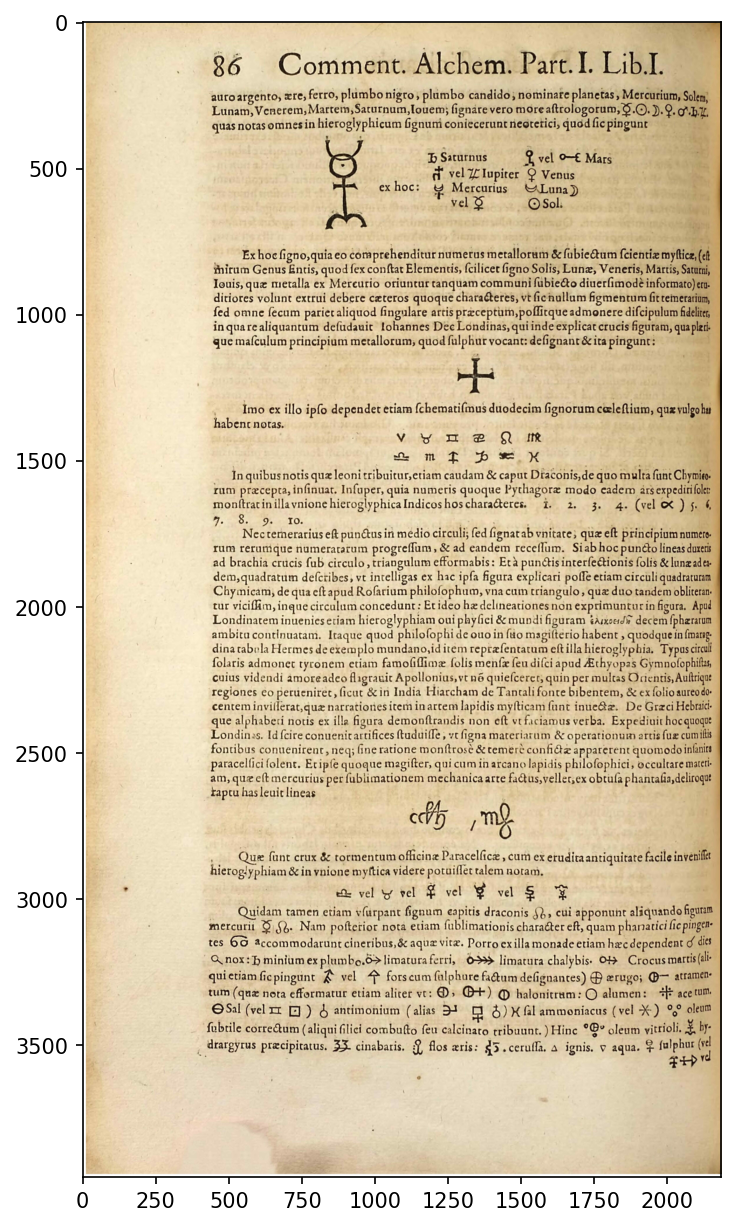

In [385]:
p = doc_pdf.load_page(96)
pix = p.get_pixmap()
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.imshow(np_array)
plt.show()

In [386]:
def get_token_coordinates(token, textblocks):
    """
    Returns the coordinates (x0, y0, x1, y1) of the ORIGINAL OCR textblock
    that produced the token.

    token.ref MUST contain:
        - "page": [int]
        - "textblock": [int]
    """

    ref = token["ref"]
    if ref is None:
        return None

    page_list = ref.get("page")
    tb_list = ref.get("textblock")

    if not page_list or not tb_list:
        return None

    page_idx = page_list[0]
    tb_idx = tb_list[0]

    try:
        tb = textblocks[page_idx][tb_idx]
        return tb["coordinates"]
    except Exception as e:
        print("Coordinate lookup failed:", e)
        return None

def attach_coordinates_to_sent_dicts(sent_dicts, textblocks):
    for sent in sent_dicts:
        for tok in sent["tokens_data"]:
            tok["coordinates"] = get_token_coordinates(tok, textblocks)
    return sent_dicts

In [387]:
sent_dicts_with_coords = attach_coordinates_to_sent_dicts(sent_dicts, textblocks)
sent_dicts_margins_with_coords = attach_coordinates_to_sent_dicts(sent_dicts_margins, textblocks)

In [388]:
[textblock for textblock in textblocks[4] if textblock["tag"] in ["header", "title", "text"]]

[{'coordinates': [752.6400146484375,
   171.59994506835938,
   1860.423095703125,
   176.3999481201172],
  'text': 'EPISTOLA DEDICATORIA.\n',
  'tag': 'header'},
 {'coordinates': [420.0,
   255.35995483398438,
   2208.9599609375,
   260.1599426269531],
  'text': 'test ex sequentibus intelligi. Triplex hodiè est medicinae docendae, facien¬\n',
  'tag': 'text'},
 {'coordinates': [424.79998779296875,
   334.7998962402344,
   2193.759765625,
   339.5998840332031],
  'text': 'daeque & ratio & familia. Primam appellant sectam dogmaticorum &\n',
  'tag': 'text'},
 {'coordinates': [420.0,
   408.9839172363281,
   2192.752685546875,
   413.9039306640625],
  'text': 'rationalium, cuius professores ab Hippocrate & Galeno Hippocratici &\n',
  'tag': 'text'},
 {'coordinates': [434.6400146484375,
   490.5599060058594,
   2202.1669921875,
   495.3598937988281],
  'text': 'Galenici nuncupantur, quia potissmum, istorum, instituta sequuntur.\n',
  'tag': 'text'},
 {'coordinates': [429.6000061035156,
   

In [389]:
[sent["sent_text"] for sent in sent_dicts_with_coords if sent["tokens_data"][-1]["ref"]["page"][-1]==96]

['Itaque nihil hodie est usitatius, quam pro septem metallis, hoc est, hydrargyro, image1 auro argento, aere, ferro, plumbo nigro, plumbo candido, nominare planetas, Mercurium, Solem, Lunam, Uenerem, Martem, Saturnum, louem;',
 'signare uero more astrologorum, Mercurius, Sol, Luna, Uenus, Mars, Saturnus, Jupiter.',
 'quas notas omnes in hieroglyphicum signum coniecerunt neoterici, quod sic pingunt ex hoc:',
 'Saturnus Saturnus Jupiter uel Jupiter.',
 'Iupiter Mercurius Mercurius uel Mercurius Mars uel Mars Mars Uenus Uenus Luna Luna Luna Sol Sol.',
 'Ex hoc signo, quia eo comprehenditur numerus metallorum & subiectum scientiae mysticae, (est mirum Genus Entis, quod sex constat Elementis, scilicet signo Solis, Lunae, Ueneris, Martis, Saturni, Iouis, quae metalla ex Mercurio oriuntur tanquam communi subiecto diuersimode informato) eruditiores uolunt extrui debere caeteros quoque characteres, ut sic nullum figmentum sit temerarium sed omne secum pariet aliquod singulare artis praeceptum, 

In [390]:
sent_dicts_margins_with_coords[:5]

[{'work_id': '100085',
  'sent_id': 0,
  'sent_text': 'In specie tot medicorum hodie sectae, ut uideantur innumerabila, genere ad tres classes reduci possunt.',
  'tokens_data': [{'token_text': 'In',
    'lemma': 'in',
    'pos': 'ADP',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 0,
    'char_end': 2,
    'coordinates': [235.44000244140625,
     684.7200317382812,
     409.4384460449219,
     689.5200805664062]},
   {'token_text': 'specie',
    'lemma': 'species',
    'pos': 'NOUN',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 3,
    'char_end': 9,
    'coordinates': [235.44000244140625,
     684.7200317382812,
     409.4384460449219,
     689.5200805664062]},
   {'token_text': 'tot',
    'lemma': 'tot',
    'pos': 'DET',
    'ref': {'page': [4], 'textblock': [0], 'tags': [], 'blocktype': 'margin'},
    'char_start': 10,
    'char_end': 13,
    'coordinates': [235.44000244140625,
  

In [391]:
page_sents = [sent for sent in sent_dicts_with_coords if sent["tokens_data"][-1]["ref"]["page"][-1]==96]

page_margins = [sent for sent in sent_dicts_margins_with_coords if sent["tokens_data"][-1]["ref"]["page"][0]==96]


In [392]:
[sent["sent_text"] for sent in page_sents[:10]]

['Itaque nihil hodie est usitatius, quam pro septem metallis, hoc est, hydrargyro, image1 auro argento, aere, ferro, plumbo nigro, plumbo candido, nominare planetas, Mercurium, Solem, Lunam, Uenerem, Martem, Saturnum, louem;',
 'signare uero more astrologorum, Mercurius, Sol, Luna, Uenus, Mars, Saturnus, Jupiter.',
 'quas notas omnes in hieroglyphicum signum coniecerunt neoterici, quod sic pingunt ex hoc:',
 'Saturnus Saturnus Jupiter uel Jupiter.',
 'Iupiter Mercurius Mercurius uel Mercurius Mars uel Mars Mars Uenus Uenus Luna Luna Luna Sol Sol.',
 'Ex hoc signo, quia eo comprehenditur numerus metallorum & subiectum scientiae mysticae, (est mirum Genus Entis, quod sex constat Elementis, scilicet signo Solis, Lunae, Ueneris, Martis, Saturni, Iouis, quae metalla ex Mercurio oriuntur tanquam communi subiecto diuersimode informato) eruditiores uolunt extrui debere caeteros quoque characteres, ut sic nullum figmentum sit temerarium sed omne secum pariet aliquod singulare artis praeceptum, 

In [393]:
page_margins[:5]

[]

In [394]:
patch_color_dict = {"title" : "green",
                    "header" : "red",
                    "footer" : "orange",
                    "margin" : "yellow",
                     "text" : "white",
}

def plot_patch(coords, blocktype, ax):
   color = patch_color_dict[blocktype]
   patch = patches.Rectangle((coords[0], coords[1]),  # Bottom left corner
                              coords[2] - coords[0],  # Width
                              coords[3] - coords[1],  # Height
                              linewidth=1, edgecolor=color, facecolor='none')
   ax.add_patch(patch) # draw candidate textblocks in black

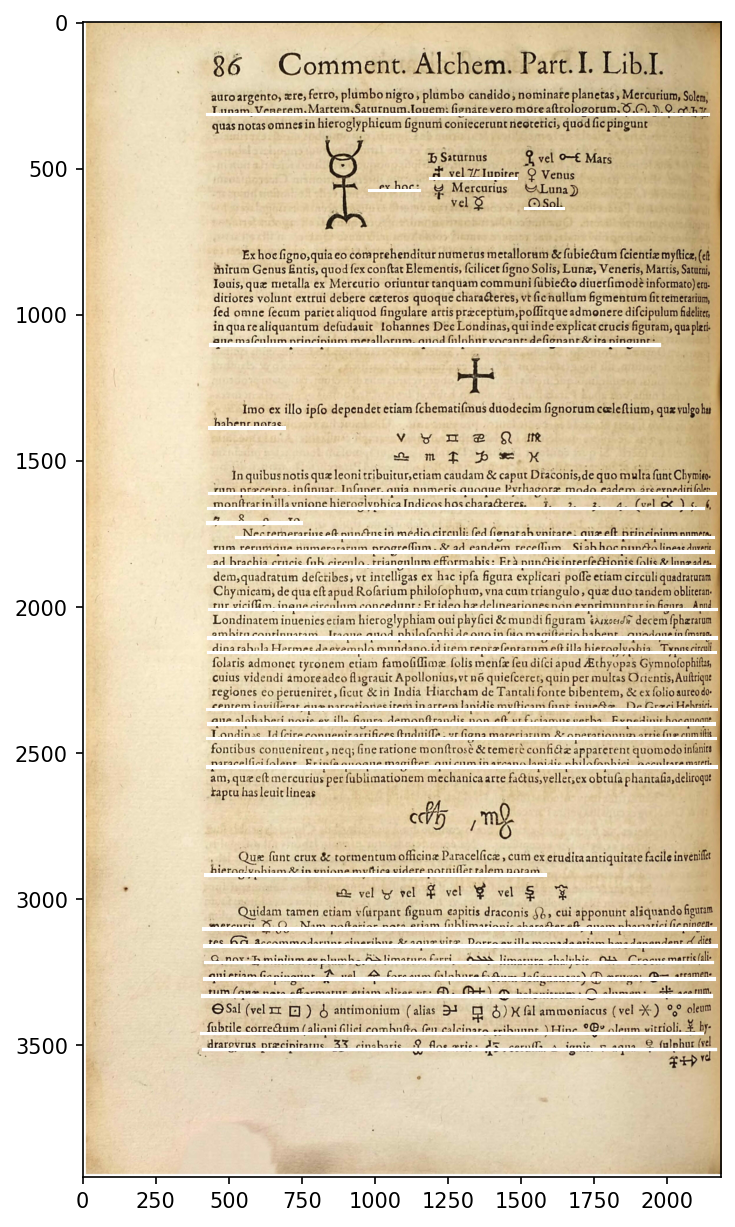

In [395]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.imshow(np_array)

for sent in page_sents:
    last_token_coords =  sent["tokens_data"][-1]["coordinates"]
    plot_patch(last_token_coords, "text", ax)

for sent in page_margins:
    first_token_coords =  sent["tokens_data"][0]["coordinates"]
    plot_patch(first_token_coords, "margin", ax)

plt.show()

In [396]:
def merge_main_and_margin_sentences(
    sent_dicts_with_coords,
    sent_dicts_margins_with_coords
):
    """
    Returns a *single merged list* of sentence dicts,
    where margin sentences are inserted after the main-text
    sentences whose last-token y0 is VERTICALLY NEAREST
    to the first-token y0 of the margin sentence (on the same page).

    MAIN SENTENCE anchor_y  = last_token.coordinates[1]
    MARGIN SENTENCE anchor_y = first_token.coordinates[1]
    """

    from collections import defaultdict

    main_by_page = defaultdict(list)
    margin_by_page = defaultdict(list)

    # --- 1. Main text: anchor = y of last token ---
    for s in sent_dicts_with_coords:
        if not s.get("tokens_data"):
            continue

        last_tok = s["tokens_data"][-1]
        coords = last_tok.get("coordinates")
        if coords is None:
            continue

        page = last_tok["ref"]["page"][-1]
        s["_anchor_y"] = float(coords[1])  # y0 of last token
        s["_page"] = page
        main_by_page[page].append(s)

    # --- 2. Margins: anchor = y of *first* token ---
    for s in sent_dicts_margins_with_coords:
        if not s.get("tokens_data"):
            continue

        first_tok = s["tokens_data"][0]
        coords = first_tok.get("coordinates")
        if coords is None:
            continue

        page = first_tok["ref"]["page"][0]
        s["_anchor_y"] = float(coords[1])  # y0 of first token
        s["_page"] = page
        margin_by_page[page].append(s)

    merged = []
    all_pages = sorted(set(main_by_page.keys()) | set(margin_by_page.keys()))

    for page in all_pages:
        mains = main_by_page.get(page, [])
        margins = margin_by_page.get(page, [])

        # If there is no main text on this page, just append margins in vertical order
        if not mains:
            for m in sorted(margins, key=lambda s: s["_anchor_y"]):
                merged.append(m)
            continue

        # Sort main sentences by their anchor_y
        mains_sorted = sorted(mains, key=lambda s: s["_anchor_y"])

        # Prepare: list of lists of margins to attach after each main
        attach_after = {i: [] for i in range(len(mains_sorted))}

        # For each margin, find nearest main *on that page*
        for m in margins:
            m_y = m["_anchor_y"]

            best_i = None
            best_dist = float("inf")
            for i, main_s in enumerate(mains_sorted):
                dist = abs(main_s["_anchor_y"] - m_y)
                if dist < best_dist:
                    best_dist = dist
                    best_i = i

            # Attach margin AFTER that main sentence
            attach_after[best_i].append(m)

        # Interleave: main, then all margins attached to it
        out_page = []
        for i, main_s in enumerate(mains_sorted):
            out_page.append(main_s)
            if attach_after[i]:
                out_page.extend(attach_after[i])

        merged.extend(out_page)

    # --- Cleanup temp fields + reassign global sent_id ---
    for new_id, s in enumerate(merged):
        s["sent_id"] = new_id
        s.pop("_anchor_y", None)
        s.pop("_page", None)

    return merged

In [397]:
page_merged_sentences = merge_main_and_margin_sentences(
    page_sents,
    page_margins
)

In [398]:
page_margin_integration_example_sents = pd.DataFrame([(sent["sent_text"], sent["tokens_data"][0]["ref"]["blocktype"]) for sent in page_merged_sentences])
page_margin_integration_example_sents.head(50)

,0,1
0,"Itaque nihil hodie est usitatius, quam pro sep...",text
1,"signare uero more astrologorum, Mercurius, Sol...",text
2,Saturnus Saturnus Jupiter uel Jupiter.,text
3,quas notas omnes in hieroglyphicum signum coni...,text
4,Iupiter Mercurius Mercurius uel Mercurius Mars...,text
5,"Ex hoc signo, quia eo comprehenditur numerus m...",text
6,quod sulphur uocant:,text
7,designant & ita pingunt:,text
8,crux Imo ex illo ipso dependet etiam schematis...,text
9,Aries Taurus Gemini Cancer ]Leo Uirgo Libra Sc...,text


In [399]:
#google_conf.set_with_dataframe(emlap_catalogue.add_worksheet("page_sents_example", 1,1), page_margin_integration_example_sents)

In [400]:
page_tokens_example = pd.DataFrame(
    (lambda d, n=n: (d.update({"sent_n": n}) or d))(t)
    for n, token_list in enumerate([sent["tokens_data"] for sent in page_merged_sentences])
    for t in token_list
)
for attr in ["page", "textblock", "tags", "blocktype"]:
    page_tokens_example[attr] = page_tokens_example.apply(lambda row: row["ref"][attr], axis=1)
page_tokens_example.drop(["ref", "coordinates"], axis=1, inplace=True)
page_tokens_example.head(5)

,token_text,lemma,pos,char_start,char_end,sent_n,page,textblock,tags,blocktype
0,Itaque,itaque,CCONJ,0,6,0,[95],[65],[],text
1,nihil,nihil,PRON,7,12,0,[95],[65],[],text
2,hodie,hodie,ADV,13,18,0,[95],[65],[],text
3,est,sum,AUX,19,22,0,[95],[65],[],text
4,usitatius,usitatior,ADJ,23,32,0,[95],[65],[],text


In [401]:
page_tokens_example

,token_text,lemma,pos,char_start,char_end,sent_n,page,textblock,tags,blocktype
0,Itaque,itaque,CCONJ,0,6,0,[95],[65],[],text
1,nihil,nihil,PRON,7,12,0,[95],[65],[],text
2,hodie,hodie,ADV,13,18,0,[95],[65],[],text
3,est,sum,AUX,19,22,0,[95],[65],[],text
4,usitatius,usitatior,ADJ,23,32,0,[95],[65],[],text
...,...,...,...,...,...,...,...,...,...,...
755,.,.,PUNCT,7,8,41,[96],[59],[],text
756,ignis,ignis,NOUN,0,5,42,[96],[59],[],text
757,.,.,PUNCT,5,6,42,[96],[59],[],text
758,aqua,aqua,NOUN,0,4,43,[96],[59],[],text


In [402]:
google_conf.set_with_dataframe(emlap_catalogue.add_worksheet("page_tokens_example_libavius_p96", 1,1), page_tokens_example)

In [334]:
textblocks[96][2:5]

[{'coordinates': [424.0799865722656,
   263.3039855957031,
   2160.621826171875,
   268.2239990234375],
  'text': 'auro argento, aere, ferro, plumbo nigro, plumbo candido, nominare planetas, Mercurium, Solem,\n',
  'tag': 'text'},
 {'coordinates': [424.0799865722656,
   312.7200622558594,
   2143.775634765625,
   317.5200500488281],
  'text': 'Lunam, Venerem, Martem, Saturnum, louem; signare vero more astrologorum,\xa0[S]Mercurius[/S],\xa0[S]Sol[/S],\xa0[S]Luna[/S],\xa0[S]Venus[/S],\xa0[S]Mars[/S],\xa0[S]Saturnus[/S],\xa0[S]Jupiter[/S].\n',
  'tag': 'text'},
 {'coordinates': [428.3999938964844,
   360.7200622558594,
   1958.1298828125,
   365.5200500488281],
  'text': 'quas notas omnes in hieroglyphicum signum coniecerunt neoterici, quòd sic pingunt\n',
  'tag': 'text'}]

In [314]:
sent_dicts_with_coords = attach_coordinates_to_sent_dicts(sent_dicts, textblocks)
sent_dicts_margins_with_coords = attach_coordinates_to_sent_dicts(sent_dicts_margins, textblocks)

merged_sentences = merge_main_and_margin_sentences(
    sent_dicts_with_coords,
    sent_dicts_margins_with_coords
)

In [315]:
len(merged_sentences)

7638

In [316]:
merged_tokens = pd.DataFrame(
    (lambda d, n=n: (d.update({"sent_n": n}) or d))(t)
    for n, token_list in enumerate([sent["tokens_data"] for sent in merged_sentences])
    for t in token_list
)
for attr in ["page", "textblock", "tags", "blocktype"]:
    merged_tokens[attr] = merged_tokens.apply(lambda row: row["ref"][attr], axis=1)
merged_tokens.drop(["ref", "coordinates"], axis=1, inplace=True)
merged_tokens.head(5)

,token_text,lemma,pos,char_start,char_end,sent_n,page,textblock,tags,blocktype
0,Commentariorum,commentarius,NOUN,0,14,0,[1],[1],[],text
1,Alchymiae,alchymius,PROPN,0,9,1,[1],[2],[],title
2,Andreae,Andreas,ADJ,0,7,2,[1],[3],[],text
3,Libauii,Libauii,PROPN,8,15,2,[1],[3],[],text
4,Med,ego,PROPN,16,19,2,[1],[3],[],text


In [317]:
len(merged_tokens)

99679

In [318]:
merged_tokens[merged_tokens["tags"].apply(lambda x: "G" in x)][:10]


,token_text,lemma,pos,char_start,char_end,sent_n,page,textblock,tags,blocktype
91659,vil,vil,ADP,7,10,6969,[91],[64],[G],text
91660,besser,gut,ADV,11,17,6969,[91],[64],[G],text
91661,daß,daß,SCONJ,18,21,6969,[91],[64],[G],text
91662,das,der,DET,22,25,6969,[91],[64],[G],text
91663,weiber,weiber,ADV,26,32,6969,[91],[64],[G],text
91664,uolck,Uolck,NOUN,33,38,6969,[91],"[64, 65]",[G],text
91683,geringe,gering,ADJ,28,35,6970,[91],"[65, 66]",[G],text
91684,haußhaltung,Haußhaltung,NOUN,36,47,6970,[91],[66],[G],text
91685,ist,sein,AUX,48,51,6970,[91],[66],[G],text
91687,gebuerth,Gebuerth,PROPN,54,62,6970,[91],[66],[G],text


In [319]:
print(merged_tokens[merged_tokens["tags"].apply(lambda x: "S" in x)].head(10))

      token_text     lemma    pos  char_start  char_end  sent_n  page  \
43471          y        ym      X           5         6    3109  [48]   
74001       iiii      iiii    NUM          11        15    5680  [74]   
95873        Sol       sol  PROPN          43        46    7216  [96]   
95875       Luna      luna  PROPN          48        52    7216  [96]   
95877      Venus     Uenus  PROPN          54        59    7216  [96]   
95879       Mars      Mars  PROPN          61        65    7216  [96]   
95881   Saturnus  Saturnus  PROPN          67        75    7216  [96]   
95883    Jupiter   Jupiter  PROPN          77        84    7216  [96]   
95885       quas       qui   PRON           0         4    7217  [96]   
95886      notas      noto   NOUN           5        10    7217  [96]   

      textblock tags blocktype  
43471       [0]  [S]    margin  
74001      [31]  [S]      text  
95873       [3]  [S]      text  
95875       [3]  [S]      text  
95877       [3]  [S]      text 

In [320]:
textblocks[96][3]

{'coordinates': [424.0799865722656,
  312.7200622558594,
  2143.775634765625,
  317.5200500488281],
 'text': 'Lunam, Venerem, Martem, Saturnum, louem; signare vero more astrologorum,\xa0[S]Mercurius[/S],\xa0[S]Sol[/S],\xa0[S]Luna[/S],\xa0[S]Venus[/S],\xa0[S]Mars[/S],\xa0[S]Saturnus[/S],\xa0[S]Jupiter[/S].\n',
 'tag': 'text'}

In [107]:
def process_file_to_v2_json(filepath, work_id, outpath, nlp):
    """
    Load OCR textblocks → build Doc → convert to v2 sentence dicts → write JSON.
    """

    # Load textblocks
    with open(filepath, 'r', encoding='utf-8') as f:
        textblocks_pages = json.load(f)

    # Build annotated doc
    doc = process_with_source_tracking(textblocks_pages, nlp)

    # Convert doc to sentence dictionaries
    sent_dicts = doc_to_sent_dicts(doc, work_id)

    # Write JSON
    with open(outpath, "w", encoding="utf-8") as f:
        json.dump(sent_dicts, f, ensure_ascii=False, indent=2)

In [109]:
sent_dicts_with_coords = attach_coordinates_to_sent_dicts(sent_dicts, textblocks)
sent_dicts_margins_with_coords = attach_coordinates_to_sent_dicts(sent_dicts_margins, textblocks)

merged_sentences = merge_main_and_margin_sentences(
    sent_dicts_with_coords,
    sent_dicts_margins_with_coords
)

In [111]:
merged_sentences[20:25]

[{'work_id': '100085',
  'sent_id': 20,
  'sent_text': 'ExpeRientia Excellentissimo Uiro, Et',
  'tokens_data': [{'token_text': 'ExpeRientia',
    'lemma': 'experientia',
    'pos': 'PROPN',
    'ref': {'page': [3],
     'textblock': [1, 2],
     'tags': None,
     'blocktype': 'title'},
    'char_start': 0,
    'char_end': 11,
    'coordinates': [194.16000366210938,
     1076.4000244140625,
     1926.0487060546875,
     1081.199951171875]},
   {'token_text': 'Excellentissimo',
    'lemma': 'excellentissimus',
    'pos': 'PROPN',
    'ref': {'page': [3], 'textblock': [2], 'tags': None, 'blocktype': 'title'},
    'char_start': 12,
    'char_end': 27,
    'coordinates': [156.24000549316406,
     1152.2401123046875,
     1933.520751953125,
     1157.0400390625]},
   {'token_text': 'Uiro',
    'lemma': 'uiro',
    'pos': 'NOUN',
    'ref': {'page': [3], 'textblock': [2], 'tags': None, 'blocktype': 'title'},
    'char_start': 28,
    'char_end': 32,
    'coordinates': [156.24000549316406,
 

In [ ]:
source_path = "../data/emlap_annotated_textblocks/"
target_path = "../data/sents_data_jsons_dicts/"
os.makedirs(target_path, exist_ok=True)

for filename in os.listdir(source_path):

    if not filename.endswith(".json"):      # textblocks files
        continue

    work_id = filename[:6]
    outpath = os.path.join(target_path, f"{work_id}.json")

    # Skip if already processed
    if os.path.exists(outpath):
        continue

    filepath = os.path.join(source_path, filename)
    print("Processing", filename)

    try:
        process_file_to_v2_json(
            filepath=filepath,
            work_id=work_id,
            outpath=outpath,
            nlp=tomela.nlp
        )
    except Exception as e:
        print("FAILED:", filename, "→", e)

In [98]:
sent_data_updated[100:120]

[('100085',
  100,
  'Non alium liquorem uesica reddunt.',
  [('Non',
    'non',
    'PART',
    (0, 3),
    {'page': [7], 'texblock': [23], 'tags': None, 'blocktype': 'text'}),
   ('alium',
    'alius',
    'DET',
    (4, 9),
    {'page': [7], 'texblock': [23], 'tags': None, 'blocktype': 'text'}),
   ('liquorem',
    'liquor',
    'NOUN',
    (10, 18),
    {'page': [7], 'texblock': [23], 'tags': None, 'blocktype': 'text'}),
   ('uesica',
    'uesica',
    'NOUN',
    (19, 25),
    {'page': [7], 'texblock': [23, 24], 'tags': None, 'blocktype': 'text'}),
   ('reddunt',
    'reddo',
    'VERB',
    (26, 33),
    {'page': [7], 'texblock': [24], 'tags': None, 'blocktype': 'text'}),
   ('.',
    '.',
    'PUNCT',
    (33, 34),
    {'page': [7], 'texblock': [24], 'tags': None, 'blocktype': 'text'})]),
 ('100085',
  101,
  'Non habent alia membra, quam nos, non sudores alios.',
  [('Non',
    'non',
    'PART',
    (0, 3),
    {'page': [7], 'texblock': [24], 'tags': None, 'blocktype': 'text'}

In [ ]:
    target_path = "/srv/data/tome/tome-corpus/sents_data_id_jsons_v4-0/"
os.makedirs(target_path, exist_ok=True)

In [ ]:
# filename_id_dict.items()

In [ ]:
source_path = "../data/emlap_annotated_textblocks/"
len(os.listdir(source_path)) # 100 for textblocks, 100 for parameters used for their extraction

In [ ]:
os.listdir(source_path)

In [ ]:
for filename in os.listdir(source_path):
    if "_params" not in filename:
            id = filename[:6]
            try:
                if id + ".json" not in os.listdir(target_path):
                    # filename = filename.replace(".pdf", ".json")
                    filepath = os.path.join(source_path, filename)
                    with open(filepath, 'r', encoding='utf-8') as f:
                            textblocks_pages = json.load(f)
                    print("currently processing: ", filename)
                    doc = process_with_source_tracking(textblocks_pages, tomela.nlp)
                    doc_sentdata = [(sent.text, [(t.text, t.lemma_, t.pos_, (t.idx - sent[0].idx, t.idx - sent[0].idx + len(t)),  {"page" : t._.pages, "texblock" : t._.textblocks}) for t in sent]) for sent in doc.sents]
                    sent_data_updated = []
                    for n_sent, sent_data in enumerate(doc_sentdata):
                            sent_data_updated.append((id, n_sent, sent_data[0], sent_data[1]))
                    with open(target_path + str(id) + ".json", "w") as f:
                            json.dump(sent_data_updated, f)
            except:
                print("failed with file: ", id, filename)
                pass

In [ ]:
fns_jsons = os.listdir(target_path)
fns_jsons[:10]

In [ ]:
len(fns_jsons)

In [ ]:
sents_data = json.load(open(target_path + fns_jsons[20], "r"))
sents_data[100:103]

In [ ]:
import os, json, pickle
prev_path   = target_path  # where your old .pickle / .json live
target_path = "../data/sents_data_jsons_dicts/"
os.makedirs(target_path, exist_ok=True)

def token_tuple_to_dict(tok):
    """
    Accepts token tuples of length 4 or 5:
      4: (text, lemma, pos, (start, end))
      5: (text, lemma, pos, (start, end), ref_dict)
    Returns a JSON-serializable dict.
    """
    if len(tok) < 4:
        raise ValueError(f"Unexpected token shape: {tok}")

    token_text, lemma, pos, span = tok[0], tok[1], tok[2], tok[3]
    if not isinstance(span, (list, tuple)) or len(span) != 2:
        raise ValueError(f"Bad span in token: {tok}")

    char_start, char_end = int(span[0]), int(span[1])

    # Optional ref at index 4
    ref = tok[4] if len(tok) >= 5 else None

    # Make sure ref is JSON-friendly
    if isinstance(ref, dict):
        page = ref.get("page")
        # convert sets/tuples to lists to be JSON-serializable
        if isinstance(page, (set, tuple)):
            page = list(page)
        ref = {
            "page": page,
            "textblock": ref.get("textblock") or ref.get("texblock")  # tolerate earlier key name
        }
    elif ref is not None:
        # unexpected type → stringify to avoid JSON errors
        ref = str(ref)

    return {
        "token_text": token_text,
        "lemma": lemma,
        "pos": pos,
        "ref": ref,                  # << stays None if we don’t have it
        "char_start": char_start,
        "char_end": char_end,
    }

def sent_tuple_to_dict(entry):
    """
    entry is typically: (work_id, sent_id, sent_text, tokens_list)
    """
    if len(entry) != 4:
        raise ValueError(f"Unexpected sentence shape: {type(entry)} {entry}")

    work_id, sent_id, sent_text, tokens_list = entry
    tokens_dicts = [token_tuple_to_dict(tok) for tok in tokens_list]
    return {
        "work_id": work_id,
        "sent_id": int(sent_id),
        "sent_text": sent_text,
        "tokens_data": tokens_dicts,
    }

def load_any(path):
    """
    Load .pickle OR .json produced by your previous run.
    Must return a list of sentence entries (tuples/lists).
    """
    if path.endswith(".pickle"):
        with open(path, "rb") as f:
            return pickle.load(f)
    elif path.endswith(".json"):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    else:
        raise ValueError(f"Unsupported file type: {path}")

for fn in os.listdir(prev_path):
    if not (fn.endswith(".pickle") or fn.endswith(".json")):
        continue

    # Keep your 6-char doc id convention if you like
    doc_id = fn[:6]
    out_path = os.path.join(target_path, f"{doc_id}.json")
    if os.path.exists(out_path):
        continue

    try:
        prev_data = load_any(os.path.join(prev_path, fn))
        # If the previous version stored only (sent_text, tokens) per sentence,
        # reconstruct work_id/sent_id here as needed:
        # e.g., prev_data == [(sent_text, tokens), ...]
        if prev_data and len(prev_data[0]) == 2:
            # synthesize (work_id, sent_id, sent_text, tokens)
            prev_data = [(doc_id, i, s[0], s[1]) for i, s in enumerate(prev_data)]

        sents_dicts = [sent_tuple_to_dict(row) for row in prev_data]

        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(sents_dicts, f, ensure_ascii=False, indent=2)

        print("wrote:", out_path)

    except Exception as e:
        print("failed:", fn, "-", e)

In [32]:
doc, doc_margins = process_with_source_tracking(textblocks[:20], tomela.nlp)

In [ ]:
lemmatized_sents_path = "/srv/data/tome/tome-corpus/lemmatized_sents_v4-0/"
try:
    os.mkdir(lemmatized_sents_path)
except:
    pass

In [ ]:
os.listdir(lemmatized_sents_path)

In [ ]:
for fn in fns_jsons:
    lemmatized_sents = []
    sents_data = json.load(open(target_path + fn, "rb"))
    print(fn)
    for (doc_id, sent_id, sent_text, sent_data) in sents_data:
        lemmasent = []
        for wordform, lemma, tag, position, t_ref in sent_data:
            if tag in ["NOUN", "PROPN", "ADJ", "VERB"]:
                lemmasent.append(lemma.lower())
        lemmatized_sents.append(" ".join(lemmasent) + "\n")
    with open(lemmatized_sents_path + fn.replace(".json", ".txt"), "w", encoding="utf-8") as f:
        f.writelines(lemmatized_sents)

In [ ]:
import shutil
shutil.copytree("/srv/data/tome/tome-corpus/lemmatized_sents_v4-0/", "../data/lemmatized_sents", dirs_exist_ok=True)
shutil.copytree("/srv/data/tome/tome-corpus/sents_data_id_jsons_v4-0/", "../data/sents_data", dirs_exist_ok=True)